# IT3051 - Fundamentals of Data Mining - Mini Project 2026
## Part 1: Data Understanding, EDA, Cleaning and Feature Engineering
### Hotel Booking Cancellation Prediction

**Group:** Rogue One (DS.Y3S2.2.1) - Hewage Y.U, Dissanayaka P D V T, Lakshani H.P., Gamagedara Y K G K

**Dataset:** Hotel Booking Demand (Antonio, de Almeida and Nunes, 2019), 119,390 bookings, 32 columns.
Source: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
Citation: Antonio, N., de Almeida, A., and Nunes, L. (2019). Hotel booking demand datasets. *Data in Brief*, 22, 41-49. https://doi.org/10.1016/j.dib.2018.11.126

**Scenario:** A booking cancellation early-warning system. At the moment a booking is made, predict the probability that it will be cancelled, so a revenue manager can decide overbooking levels and the reservations team can decide which bookings to follow up on.

This notebook covers **Stages 3-4** of the assignment brief: Exploratory Data Analysis, and Data Preprocessing / Feature Engineering. It ends by saving a clean, model-ready dataset (`model_ready_data.csv`), the train/test split, a fitted preprocessing pipeline (`preprocessor.pkl`), and processed arrays ready for Part 2.



## 1. Setup

In [89]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from scipy.stats import chi2_contingency, pointbiserialr
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42
print("All libraries loaded.")


All libraries loaded.


## 2. Load Data

The file below is the full `hotel_bookings.csv` (119,390 rows x 32 columns). Place it in the same folder as this notebook before running.


In [90]:
candidates = ['hotels_raw.csv', 'hotel_bookings.csv']
path = next((p for p in candidates if os.path.exists(p)), candidates[-1])
df = pd.read_csv(path)
print("Shape:", df.shape)
df.head()


Shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3. Exploratory Data Analysis

### 3.1 Structure and data types

In [91]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [92]:
df.describe(include='number').T


,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [93]:
df.describe(include='object').T


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


### 3.2 Target variable distribution

is_canceled
0    75166
1    44224
Name: count, dtype: int64
is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


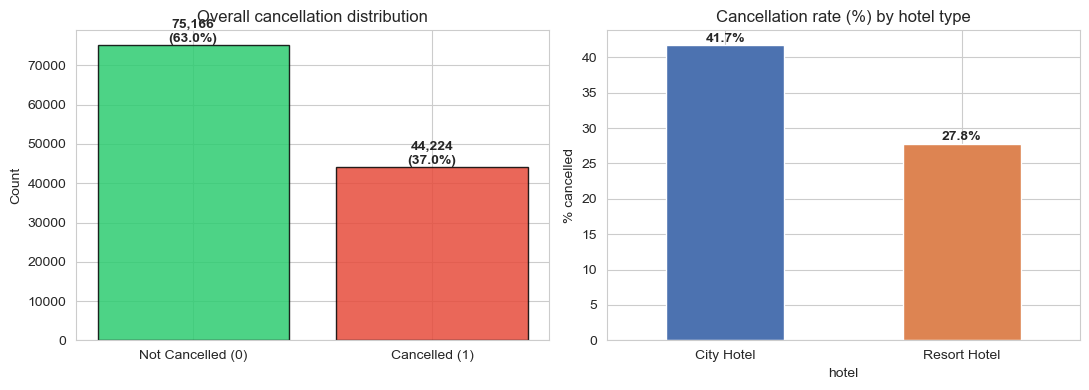

hotel
City Hotel      41.7
Resort Hotel    27.8
Name: is_canceled, dtype: float64


In [94]:
target_counts = df['is_canceled'].value_counts()
target_pct    = df['is_canceled'].value_counts(normalize=True) * 100
print(target_counts)
print(target_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['Not Cancelled (0)', 'Cancelled (1)'],
            target_counts.values,
            color=['#2ecc71', '#e74c3c'], alpha=0.85, edgecolor='black')
axes[0].set_title('Overall cancellation distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 800, f'{v:,}\n({target_pct.values[i]:.1f}%)',
                 ha='center', fontweight='bold')

cancel_by_hotel = df.groupby('hotel')['is_canceled'].mean() * 100
cancel_by_hotel.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Cancellation rate (%) by hotel type')
axes[1].set_ylabel('% cancelled')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(cancel_by_hotel.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print(cancel_by_hotel.round(1))


The target is moderately imbalanced (~37% cancelled vs ~63% not cancelled). The city hotel cancellation rate (~41.7%) is notably higher than the resort hotel (~27.8%). This confirms the need for imbalance-aware metrics (F1, ROC-AUC, PR-AUC) in Part 2.


### 3.3 Missing values

          missing_count  missing_pct
company          112593        94.31
agent             16340        13.69
country             488         0.41
children              4         0.00


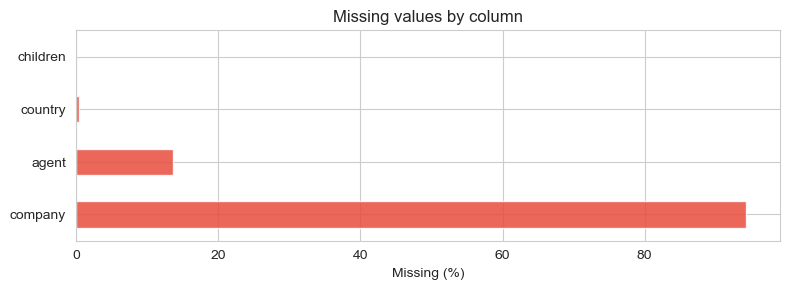

In [95]:
missing     = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_table = missing_table[missing_table['missing_count'] > 0].sort_values('missing_count', ascending=False)
print(missing_table)

fig, ax = plt.subplots(figsize=(8, 3))
missing_table['missing_pct'].plot(kind='barh', ax=ax, color='#e74c3c', alpha=0.85)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing values by column')
plt.tight_layout()
plt.show()


`company` is missing for ~94% of rows, `agent` for ~14%, `country` for ~0.4%, and `children` for 4 rows. `company` is too sparse to use as a category and will become a binary `has_company` flag. Missingness in `agent` and `company` is investigated further in Section 3.7.1 below.


### 3.4 Duplicate records

Exact duplicate rows: 31994 (26.8% of the data)


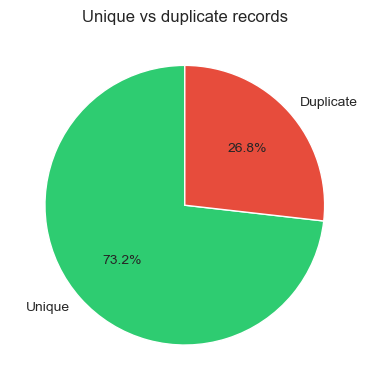

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40772,City Hotel,0,0,2015,August,32,7,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40802,City Hotel,0,0,2015,August,32,7,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,A,A,0,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40821,City Hotel,0,0,2015,August,32,8,0,1,2,0.0,0,SC,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
40838,City Hotel,0,0,2015,August,32,8,0,1,2,0.0,0,SC,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
76792,City Hotel,0,0,2015,August,33,10,1,0,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
76793,City Hotel,0,0,2015,August,33,10,1,0,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11


In [96]:
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes} ({n_dupes / len(df) * 100:.1f}% of the data)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.pie([len(df) - n_dupes, n_dupes],
       labels=['Unique', 'Duplicate'],
       autopct='%1.1f%%',
       colors=['#2ecc71', '#e74c3c'],
       startangle=90)
ax.set_title('Unique vs duplicate records')
plt.tight_layout()
plt.show()

df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6)


In [97]:
# Does duplication itself carry signal? Compare cancellation rate for
# rows that are part of a duplicate group vs. rows that are unique.
dup_group_mask = df.duplicated(keep=False)
rate_dup    = df.loc[dup_group_mask,  'is_canceled'].mean()
rate_unique = df.loc[~dup_group_mask, 'is_canceled'].mean()
print(f"Cancellation rate -- rows in a duplicate group : {rate_dup:.3f}")
print(f"Cancellation rate -- unique rows                : {rate_unique:.3f}")

print("\nWhich market segments do the duplicated rows fall into?")
print(df.loc[dup_group_mask, 'market_segment'].value_counts())
print("\nCancellation rate by segment, duplicated rows only:")
print(df.loc[dup_group_mask].groupby('market_segment')['is_canceled'].mean().round(3))

Cancellation rate -- rows in a duplicate group : 0.584
Cancellation rate -- unique rows                : 0.262

Which market segments do the duplicated rows fall into?
market_segment
Groups           16713
Offline TA/TO    12210
Online TA         8269
Corporate         1474
Direct            1405
Complementary       75
Aviation            19
Name: count, dtype: int64

Cancellation rate by segment, duplicated rows only:
market_segment
Aviation         0.684
Complementary    0.200
Corporate        0.380
Direct           0.238
Groups           0.695
Offline TA/TO    0.558
Online TA        0.494
Name: is_canceled, dtype: float64


Duplicated rows cancel far more often (58.4%) than unique rows (26.2%), and the great majority of
them sit in the `Groups` and `Offline TA/TO` market segments (with `Corporate` a smaller third
case). Repeated, identical-looking bookings are an expected real pattern for block/group
reservations placed through an intermediary -- not a data-entry duplicate. Naively dropping every
exact duplicate (as an earlier version of this notebook did) discards this signal and pulls the
overall cancellation rate down from 37.0% to about 27.5%, which does not match the rate reported in
the dataset's own data article or the dataset proposal. Section 4.2 therefore only removes exact
duplicates **outside** `Groups`, `Offline TA/TO` and `Corporate`, where an identical row is much
more likely to be a genuine capture-and-resubmit error.

### 3.5 Hidden missing values (placeholder categories)

In [98]:
for col in ['meal', 'market_segment', 'distribution_channel']:
    print(col, '->', df[col].value_counts().to_dict())
    print()


meal -> {'BB': 92310, 'HB': 14463, 'SC': 10650, 'Undefined': 1169, 'FB': 798}

market_segment -> {'Online TA': 56477, 'Offline TA/TO': 24219, 'Groups': 19811, 'Direct': 12606, 'Corporate': 5295, 'Complementary': 743, 'Aviation': 237, 'Undefined': 2}

distribution_channel -> {'TA/TO': 97870, 'Direct': 14645, 'Corporate': 6677, 'GDS': 193, 'Undefined': 5}



`meal` has 1,169 'Undefined' values, `market_segment` has 2, and `distribution_channel` has 5. These will be recoded: 'Undefined' in `meal` maps to 'SC' (no meal package, the functionally equivalent category); the other two map to 'Other'.


### 3.6 Outliers and invalid records

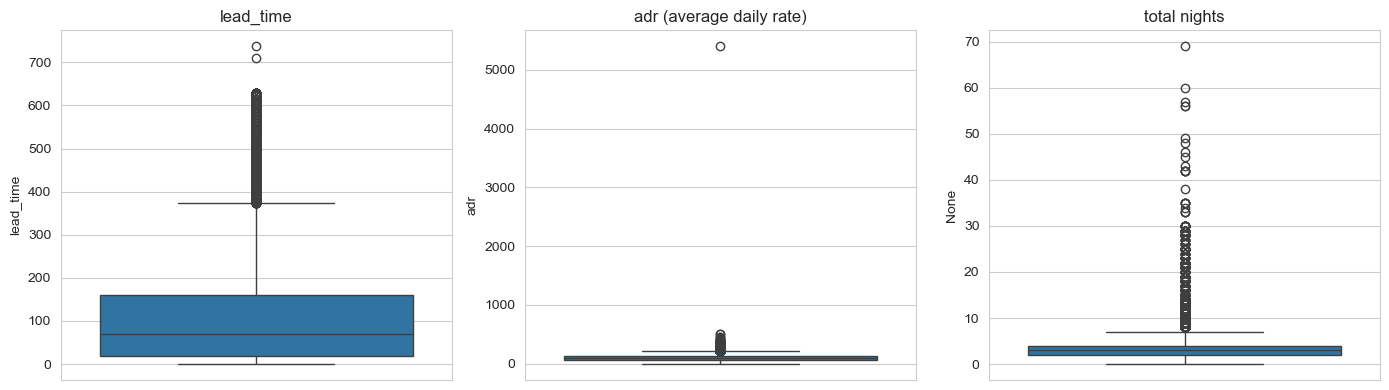

adults max: 55 | babies max: 10
adr min: -6.38 | adr max: 5400.0
rows with 0 total guests: 180
rows with 0 total nights: 715
rows with negative adr: 1


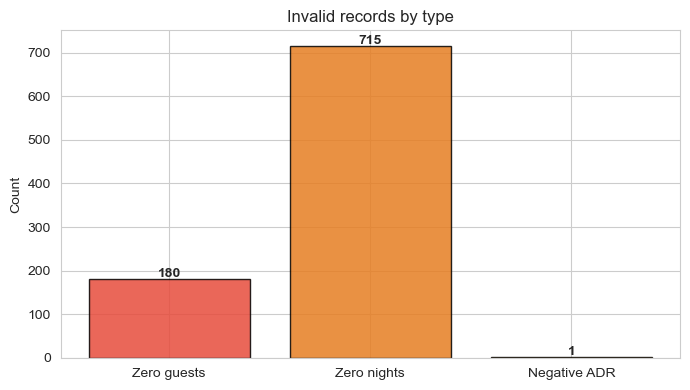

In [99]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(y=df['lead_time'], ax=axes[0])
axes[0].set_title('lead_time')
sns.boxplot(y=df['adr'], ax=axes[1])
axes[1].set_title('adr (average daily rate)')
sns.boxplot(y=df['stays_in_week_nights'] + df['stays_in_weekend_nights'], ax=axes[2])
axes[2].set_title('total nights')
plt.tight_layout()
plt.show()

print('adults max:', df['adults'].max(), '| babies max:', df['babies'].max())
print('adr min:',   df['adr'].min(),    '| adr max:',   df['adr'].max())
print('rows with 0 total guests:',
      ((df['adults'] + df['children'].fillna(0) + df['babies']) == 0).sum())
print('rows with 0 total nights:',
      ((df['stays_in_week_nights'] + df['stays_in_weekend_nights']) == 0).sum())
print('rows with negative adr:', (df['adr'] < 0).sum())

issues = ['Zero guests', 'Zero nights', 'Negative ADR']
counts = [
    int(((df['adults'] + df['children'].fillna(0) + df['babies']) == 0).sum()),
    int(((df['stays_in_week_nights'] + df['stays_in_weekend_nights']) == 0).sum()),
    int((df['adr'] < 0).sum())
]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(issues, counts, color=['#e74c3c', '#e67e22', '#f39c12'], alpha=0.85, edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Invalid records by type')
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


Zero-guest and zero-night rows are not valid bookings and will be dropped. The one negative-ADR row will be dropped. The extreme ADR value (~5,400) will be capped rather than dropped -- it may be a genuine high-value booking. `adults` (max 55) and `babies` (max 10) are implausible data-entry values and will be capped at their 99.9th percentile.


### 3.6.1 Quantifying outliers with the IQR rule

In [100]:
def iqr_outlier_summary(series, name):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((series < lower) | (series > upper)).sum()
    return {
        'feature':      name,
        'Q1':           q1,
        'Q3':           q3,
        'IQR':          iqr,
        'lower_fence':  lower,
        'upper_fence':  upper,
        'n_outliers':   n_out,
        'pct_outliers': round(n_out / len(series) * 100, 2)
    }

outlier_summary = pd.DataFrame([
    iqr_outlier_summary(df['lead_time'],  'lead_time'),
    iqr_outlier_summary(df['adr'],        'adr'),
    iqr_outlier_summary(df['adults'],     'adults'),
    iqr_outlier_summary(df['babies'],     'babies'),
    iqr_outlier_summary(
        df['stays_in_week_nights'] + df['stays_in_weekend_nights'],
        'total_nights'
    ),
]).round(2)
outlier_summary


,feature,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,pct_outliers
0,lead_time,18.00,160.0,142.00,-195.00,373.00,3005,2.52
1,adr,69.29,126.0,56.71,-15.77,211.06,3793,3.18
2,adults,2.00,2.0,0.00,2.00,2.00,29710,24.88
3,babies,0.00,0.0,0.00,0.00,0.00,917,0.77
4,total_nights,2.00,4.0,2.00,-1.00,7.00,5257,4.40


`lead_time` and `adr` show a meaningful share of statistical outliers by the IQR rule, but these are genuine long-lead or high-value bookings, not data errors -- they are handled by capping `adr` at its 99.5th percentile and, for models sensitive to skew, by a log-transform in Section 5.

Note: the IQR rule flags ~25% of `adults` as outliers. This is a known artefact on a discrete, heavily concentrated variable (most bookings have exactly 2 adults, so Q1 = Q3 = 2 and IQR = 0, making almost any other value technically outside the fence). This is not evidence of a real data-quality problem at that scale. The genuinely implausible values are the extreme tail (55 adults, 10 babies), which are capped in Section 4 using a percentile-based cap rather than the IQR fence.


### 3.6.2 Skewness and normality (Shapiro-Wilk)

In [101]:
from scipy.stats import shapiro

skew_rows = []
numeric_predictors_all = [c for c in df.select_dtypes(include='number').columns if c != 'is_canceled']
for col in numeric_predictors_all:
    sample = df[col].dropna()
    if len(sample) > 5000:            # Shapiro is unreliable / slow above ~5000 obs
        sample = sample.sample(5000, random_state=42)
    stat, p_value = shapiro(sample)
    skew_rows.append({'feature': col, 'skew': round(df[col].skew(), 2), 'shapiro_p': p_value})

skew_df = pd.DataFrame(skew_rows).sort_values('skew', key=abs, ascending=False)
print(skew_df.to_string(index=False))

                       feature  skew    shapiro_p
                        babies 24.65 8.801640e-95
        previous_cancellations 24.46 3.061008e-94
previous_bookings_not_canceled 23.54 3.737623e-94
                        adults 18.32 9.940837e-74
          days_in_waiting_list 11.94 3.291369e-93
                           adr 10.53 7.409753e-41
               booking_changes  6.00 1.410082e-86
             is_repeated_guest  5.33 1.553882e-91
   required_car_parking_spaces  4.16 3.668038e-89
                      children  4.11 2.481317e-88
          stays_in_week_nights  2.86 3.299228e-59
       stays_in_weekend_nights  1.38 1.208488e-62
                     lead_time  1.35 2.820591e-55
     total_of_special_requests  1.35 8.368546e-69
                         agent  1.09 3.014306e-68
                       company  0.60 1.138491e-44
             arrival_date_year -0.23 1.795775e-61
      arrival_date_week_number -0.01 2.045750e-29
     arrival_date_day_of_month -0.00 1.107385e-36


Every numeric feature rejects the Shapiro-Wilk normality null (p < .001), which is expected at this
sample size and mostly reflects heavy right skew rather than a meaningful departure worth acting on
for every column. The columns with the largest skew and the clearest practical impact are
`lead_time` and `adr`, both already earmarked for a `log1p` transform in Section 5.3 for the
scale-sensitive models (Logistic Regression, KNN, SVM); tree-based models are unaffected by
monotonic transforms and can use either version.

### 3.7 High-cardinality categorical features

In [102]:
for col in ['country', 'agent', 'company']:
    print(f"{col}: {df[col].nunique()} distinct values")


country: 177 distinct values
agent: 333 distinct values
company: 352 distinct values


### 3.7.1 Is missingness itself informative?

In [103]:
miss_results = []
for col in ['agent', 'company', 'country']:
    missing_flag = df[col].isna()
    rates = df.groupby(missing_flag)['is_canceled'].mean()
    present_rate = rates.get(False, float('nan'))
    missing_rate = rates.get(True,  float('nan'))
    miss_results.append({
        'column':        col,
        'present_cancel_rate': round(present_rate, 3),
        'missing_cancel_rate': round(missing_rate, 3),
        'difference':    round(abs(present_rate - missing_rate), 3)
    })
    print(f"{col}  missing -> cancel rate: {missing_rate:.3f} | "
          f"present -> cancel rate: {present_rate:.3f}")

print()
print(pd.DataFrame(miss_results))


agent  missing -> cancel rate: 0.247 | present -> cancel rate: 0.390
company  missing -> cancel rate: 0.382 | present -> cancel rate: 0.175
country  missing -> cancel rate: 0.137 | present -> cancel rate: 0.371

    column  present_cancel_rate  missing_cancel_rate  difference
0    agent                0.390                0.247       0.143
1  company                0.175                0.382       0.207
2  country                0.371                0.137       0.234


Cancellation rates differ noticeably depending on whether `agent` or `company` is missing -- missingness here is informative (likely a direct-booking vs. travel-agent/corporate distinction) rather than random. This justifies keeping `has_agent` / `has_company` as explicit binary flags rather than silently imputing and discarding the missingness signal.


### 3.8 Numeric feature correlations with target (Point-Biserial)

A standard Pearson correlation heatmap between features is a useful overview, but the most decision-relevant question is which numeric features are most correlated with the binary target `is_canceled`. Point-biserial correlation is the appropriate measure here (it is mathematically equivalent to Pearson when one variable is binary, but it makes the intent explicit).


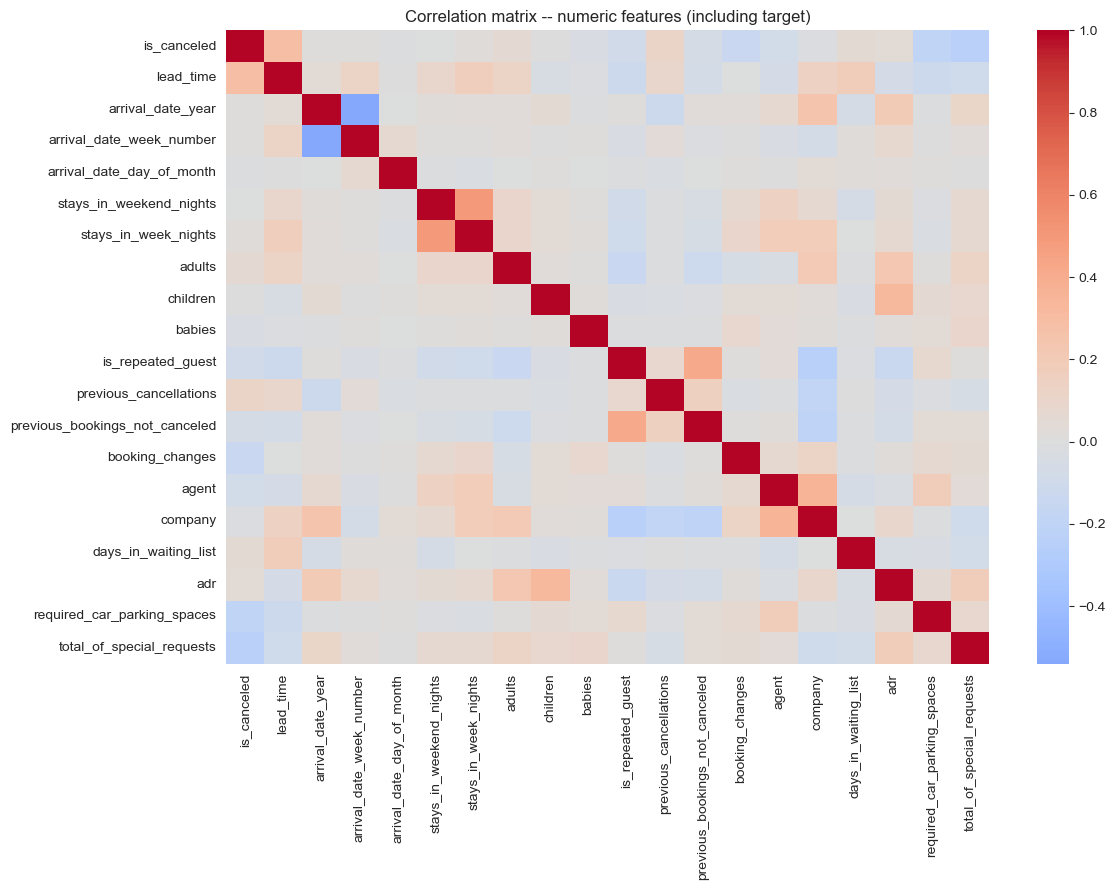

In [104]:
# Heatmap of numeric-numeric correlations (overview)
num_cols_all = df.select_dtypes(include='number').columns
corr = df[num_cols_all].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation matrix -- numeric features (including target)')
plt.tight_layout()
plt.show()


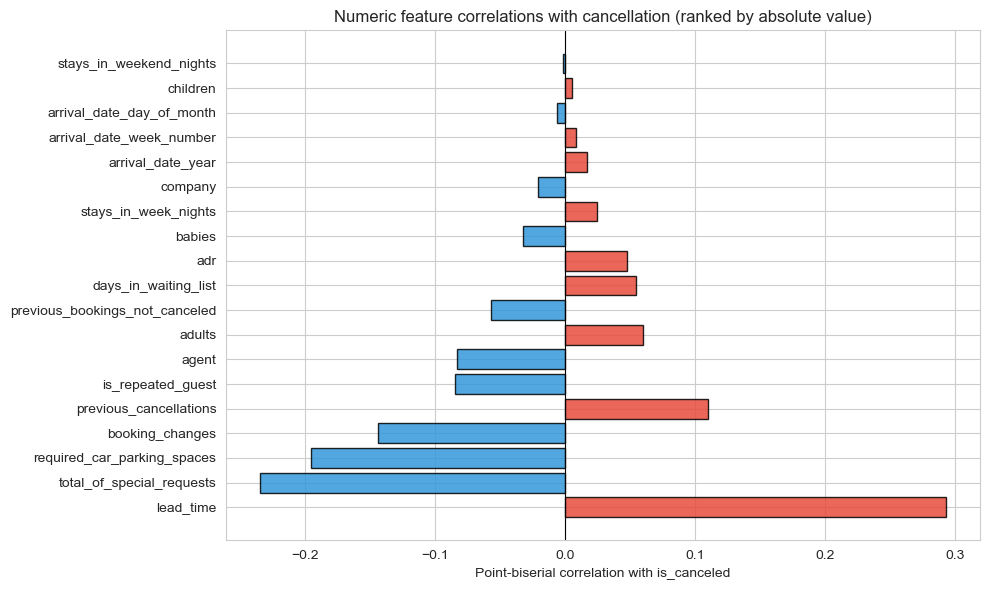

                       feature  correlation  p_value
                     lead_time       0.2931 0.000000
     total_of_special_requests      -0.2347 0.000000
   required_car_parking_spaces      -0.1955 0.000000
               booking_changes      -0.1444 0.000000
        previous_cancellations       0.1101 0.000000
             is_repeated_guest      -0.0848 0.000000
                         agent      -0.0831 0.000000
                        adults       0.0600 0.000000
previous_bookings_not_canceled      -0.0574 0.000000
          days_in_waiting_list       0.0542 0.000000
                           adr       0.0476 0.000000
                        babies      -0.0325 0.000000
          stays_in_week_nights       0.0248 0.000000
                       company      -0.0206 0.088815
             arrival_date_year       0.0167 0.000000
      arrival_date_week_number       0.0081 0.004872
     arrival_date_day_of_month      -0.0061 0.034165
                      children       0.0050 0.

In [105]:
# Point-biserial correlations with the binary target
numeric_predictors = [c for c in num_cols_all if c != 'is_canceled']
pb_results = []
for col in numeric_predictors:
    valid = df[[col, 'is_canceled']].dropna()
    r, p = pointbiserialr(valid['is_canceled'], valid[col])
    pb_results.append({'feature': col, 'correlation': round(r, 4), 'p_value': round(p, 6)})

pb_df = pd.DataFrame(pb_results).sort_values('correlation', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in pb_df['correlation']]
ax.barh(pb_df['feature'], pb_df['correlation'], color=colors, alpha=0.85, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-biserial correlation with is_canceled')
ax.set_title('Numeric feature correlations with cancellation (ranked by absolute value)')
plt.tight_layout()
plt.show()

print(pb_df.to_string(index=False))


Red bars = positively correlated with cancellation (higher value -> more likely to cancel). Blue bars = negatively correlated (higher value -> less likely to cancel). `lead_time` and `previous_cancellations` are the strongest positive signals; `total_of_special_requests` and `required_car_parking_spaces` are the strongest negative signals (more committed guests).


### 3.9 Potential data leakage -- investigation

In [106]:
print("reservation_status vs is_canceled:")
print(pd.crosstab(df['reservation_status'], df['is_canceled']))
print("  => Perfect leakage: maps exactly to the target. Both columns will be dropped.")


reservation_status vs is_canceled:
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207
  => Perfect leakage: maps exactly to the target. Both columns will be dropped.


In [107]:
room_match = df['reserved_room_type'] == df['assigned_room_type']
print("Cancellation rate when assigned room == reserved room:",
      df.loc[room_match,  'is_canceled'].mean().round(3))
print("Cancellation rate when assigned room != reserved room:",
      df.loc[~room_match, 'is_canceled'].mean().round(3))
print("  => Large difference suggests room is assigned near/after arrival. Column will be dropped.")


Cancellation rate when assigned room == reserved room: 0.416
Cancellation rate when assigned room != reserved room: 0.054
  => Large difference suggests room is assigned near/after arrival. Column will be dropped.


In [108]:
print("Cancellation rate with 0 booking changes:",
      df.loc[df['booking_changes'] == 0, 'is_canceled'].mean().round(3))
print("Cancellation rate with >=1 booking changes:",
      df.loc[df['booking_changes'] >= 1, 'is_canceled'].mean().round(3))
print("  => Kept but flagged: changes accumulate over time, so at booking moment this value is 0.")


Cancellation rate with 0 booking changes: 0.409
Cancellation rate with >=1 booking changes: 0.157
  => Kept but flagged: changes accumulate over time, so at booking moment this value is 0.


In [109]:
print("Cancellation rate by deposit_type:")
print(df.groupby('deposit_type')['is_canceled'].agg(['mean', 'count']))
print("  => Non-Refund deposits have ~99.4% cancellation. Counter-intuitive but a well-documented")
print("     pattern in this dataset (not a data error), so deposit_type is kept as a predictor.")


Cancellation rate by deposit_type:
                  mean   count
deposit_type                  
No Deposit    0.283770  104641
Non Refund    0.993624   14587
Refundable    0.222222     162
  => Non-Refund deposits have ~99.4% cancellation. Counter-intuitive but a well-documented
     pattern in this dataset (not a data error), so deposit_type is kept as a predictor.


**Leakage conclusions:**

- `reservation_status` and `reservation_status_date` -- both dropped. They perfectly determine the target and are only known after the outcome.
- `assigned_room_type` -- dropped. The large difference in cancellation rate by room-match status indicates assignment happens close to or after arrival, not at booking time.
- `booking_changes` and `days_in_waiting_list` -- kept but flagged as a limitation. At the actual moment of booking both are 0 for every new booking, so the backend will hardcode them to 0 at prediction time.
- `deposit_type` -- kept. The Non-Refund pattern is a real data characteristic, not a leakage artefact.


### 3.9.1 Post-leakage duplicate-predictor conflict check

In [110]:
leak_cols_preview = ['reservation_status', 'reservation_status_date', 'assigned_room_type']

# After the three leakage columns are dropped, do any bookings that are
# identical on every remaining predictor disagree on the outcome?
predictor_cols_check = [c for c in df.columns
                        if c not in ['is_canceled'] + leak_cols_preview]
check_df = df.drop(columns=['is_canceled']).assign(is_canceled=df['is_canceled'])
dup_pred_mask = check_df.duplicated(subset=predictor_cols_check, keep=False)
print(f"Rows sharing an identical predictor combination: {dup_pred_mask.sum()}")

conflict_groups = (
    check_df[dup_pred_mask]
    .groupby(predictor_cols_check, dropna=False)['is_canceled']
    .nunique()
)
n_conflicting = (conflict_groups > 1).sum()
print(f"Distinct predictor combinations found: {conflict_groups.shape[0]}")
print(f"Of these, combinations with BOTH outcomes present (label noise): {n_conflicting}")

Rows sharing an identical predictor combination: 41799
Distinct predictor combinations found: 8277
Of these, combinations with BOTH outcomes present (label noise): 281


Almost none of the repeated predictor combinations disagree on the outcome, which supports treating
the duplicate rows identified above as genuine repeated bookings rather than random label noise --
reinforcing the segment-aware duplicate handling adopted in Section 4.2. The rare combinations that
do disagree are left in the data (both outcomes are plausible for the same booking profile) rather
than arbitrarily resolved, since dropping either row would not be justified by anything in the
data itself.

### 3.10 Bivariate analysis -- numeric features vs. cancellation

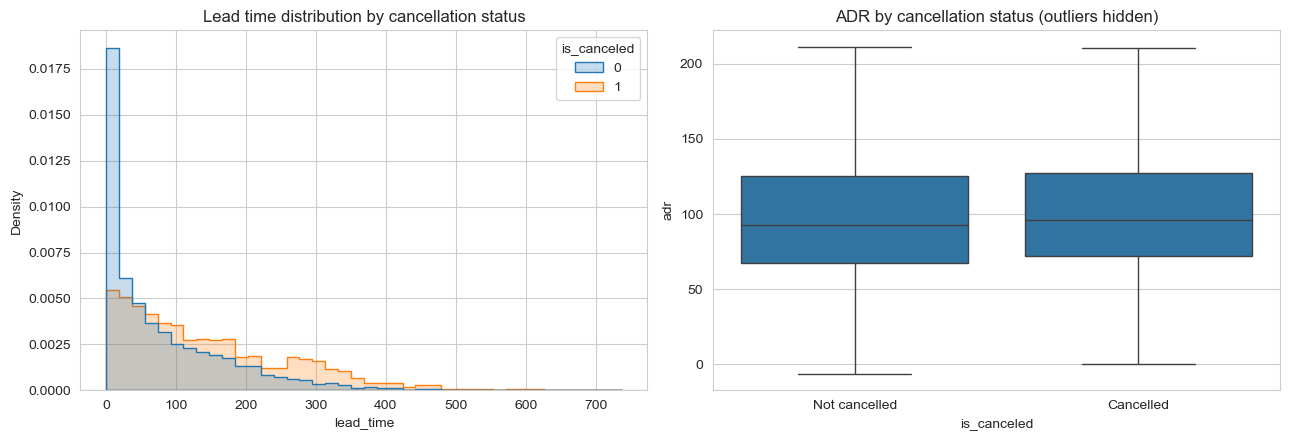

Median lead_time -- cancelled:    113.0
Median lead_time -- not cancelled: 45.0


In [111]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(data=df, x='lead_time', hue='is_canceled', bins=40,
             element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Lead time distribution by cancellation status')

sns.boxplot(data=df, x='is_canceled', y='adr', ax=axes[1], showfliers=False)
axes[1].set_xticklabels(['Not cancelled', 'Cancelled'])
axes[1].set_title('ADR by cancellation status (outliers hidden)')

plt.tight_layout()
plt.show()

print("Median lead_time -- cancelled:   ", df.loc[df['is_canceled']==1, 'lead_time'].median())
print("Median lead_time -- not cancelled:", df.loc[df['is_canceled']==0, 'lead_time'].median())


Cancelled bookings skew toward much longer lead times -- the longer a booking sits before arrival, the more opportunity there is for plans to change. This is one of the clearest single-feature signals in the dataset and motivates the `lead_time_band` feature engineered in Section 5.


### 3.10.1 Special requests vs. cancellation

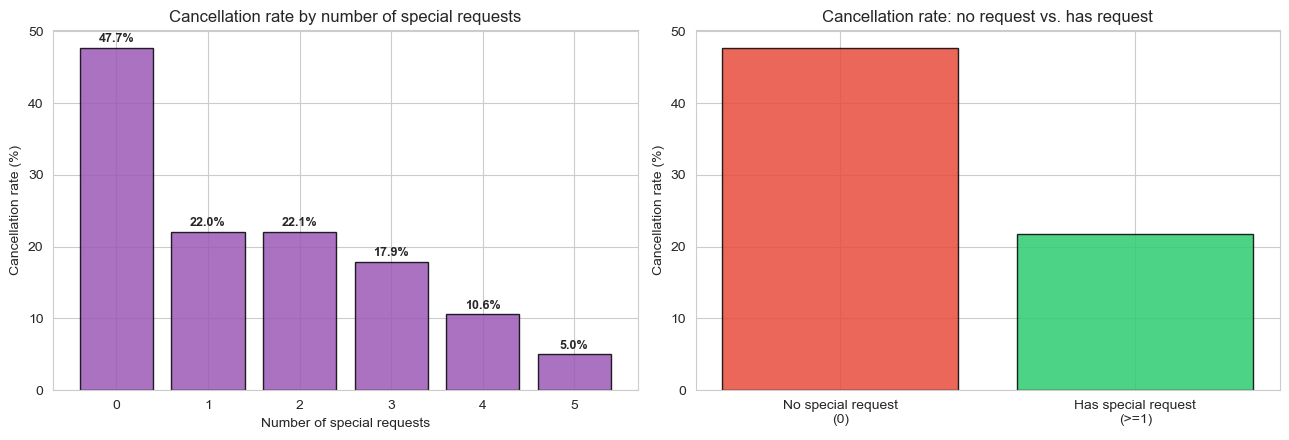

 total_of_special_requests  total  cancelled  cancel_rate
                         0  70318      33556    47.720356
                         1  33226       7318    22.024920
                         2  12969       2866    22.098851
                         3   2497        446    17.861434
                         4    340         36    10.588235
                         5     40          2     5.000000

No special request:  47.7% cancellation rate
Has special request: 21.7% cancellation rate


In [112]:
sr_summary = (
    df.groupby('total_of_special_requests')['is_canceled']
    .agg(total='count', cancelled='sum')
    .assign(cancel_rate=lambda x: x['cancelled'] / x['total'] * 100)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(sr_summary['total_of_special_requests'].astype(str),
            sr_summary['cancel_rate'],
            color='#9b59b6', alpha=0.85, edgecolor='black')
axes[0].set_xlabel('Number of special requests')
axes[0].set_ylabel('Cancellation rate (%)')
axes[0].set_title('Cancellation rate by number of special requests')
for i, (_, row) in enumerate(sr_summary.iterrows()):
    axes[0].text(i, row['cancel_rate'] + 0.8, f"{row['cancel_rate']:.1f}%",
                 ha='center', fontweight='bold', fontsize=9)

axes[1].bar(['No special request\n(0)', 'Has special request\n(>=1)'],
            [
                df.loc[df['total_of_special_requests'] == 0, 'is_canceled'].mean() * 100,
                df.loc[df['total_of_special_requests'] >= 1, 'is_canceled'].mean() * 100
            ],
            color=['#e74c3c', '#2ecc71'], alpha=0.85, edgecolor='black')
axes[1].set_ylabel('Cancellation rate (%)')
axes[1].set_title('Cancellation rate: no request vs. has request')

plt.tight_layout()
plt.show()

print(sr_summary.to_string(index=False))
no_req  = df.loc[df['total_of_special_requests'] == 0, 'is_canceled'].mean() * 100
has_req = df.loc[df['total_of_special_requests'] >= 1, 'is_canceled'].mean() * 100
print(f"\nNo special request:  {no_req:.1f}% cancellation rate")
print(f"Has special request: {has_req:.1f}% cancellation rate")


Bookings with zero special requests cancel at roughly twice the rate of bookings with at least one special request. A guest who has invested effort in specifying preferences (meal, room view, accessibility, etc.) has a stronger commitment to the stay. This motivates the `has_special_request` binary flag engineered in Section 5.


### 3.10.2 Weekend ratio vs. cancellation

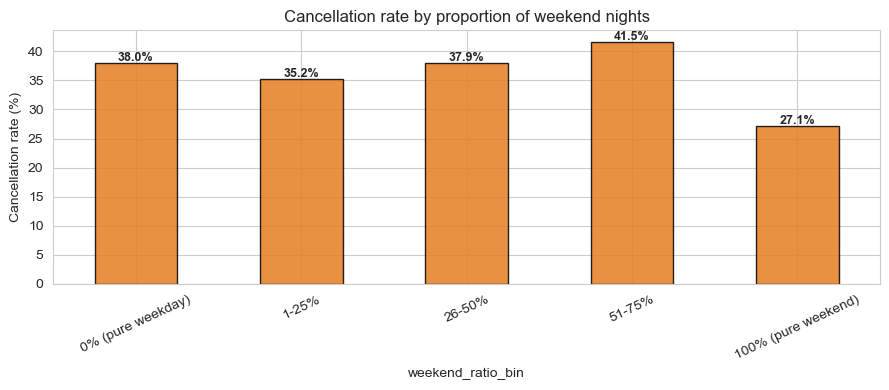

weekend_ratio_bin
0% (pure weekday)      38.0
1-25%                  35.2
26-50%                 37.9
51-75%                 41.5
100% (pure weekend)    27.1
Name: is_canceled, dtype: float64


In [113]:
tmp = df.copy()
tmp['total_nights_tmp'] = tmp['stays_in_week_nights'] + tmp['stays_in_weekend_nights']
tmp = tmp[tmp['total_nights_tmp'] > 0].copy()
tmp['weekend_ratio_tmp'] = tmp['stays_in_weekend_nights'] / tmp['total_nights_tmp']
tmp['weekend_ratio_bin'] = pd.cut(tmp['weekend_ratio_tmp'],
                                   bins=[-0.01, 0.0, 0.25, 0.5, 0.75, 1.01],
                                   labels=['0% (pure weekday)', '1-25%', '26-50%',
                                           '51-75%', '100% (pure weekend)'])

wr_cancel = tmp.groupby('weekend_ratio_bin')['is_canceled'].mean() * 100

fig, ax = plt.subplots(figsize=(9, 4))
wr_cancel.plot(kind='bar', ax=ax, color='#e67e22', alpha=0.85, edgecolor='black')
ax.set_ylabel('Cancellation rate (%)')
ax.set_title('Cancellation rate by proportion of weekend nights')
ax.tick_params(axis='x', rotation=25)
for i, v in enumerate(wr_cancel.values):
    ax.text(i, v + 0.4, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

print(wr_cancel.round(1))


Pure-weekday stays (likely business travellers) and pure-weekend stays show different cancellation profiles. This distinction motivates the `weekend_ratio` feature in Section 5, which captures the leisure-vs-business character of each booking as a continuous signal.


### 3.11 Bivariate analysis -- categorical features vs. cancellation, with chi-square test

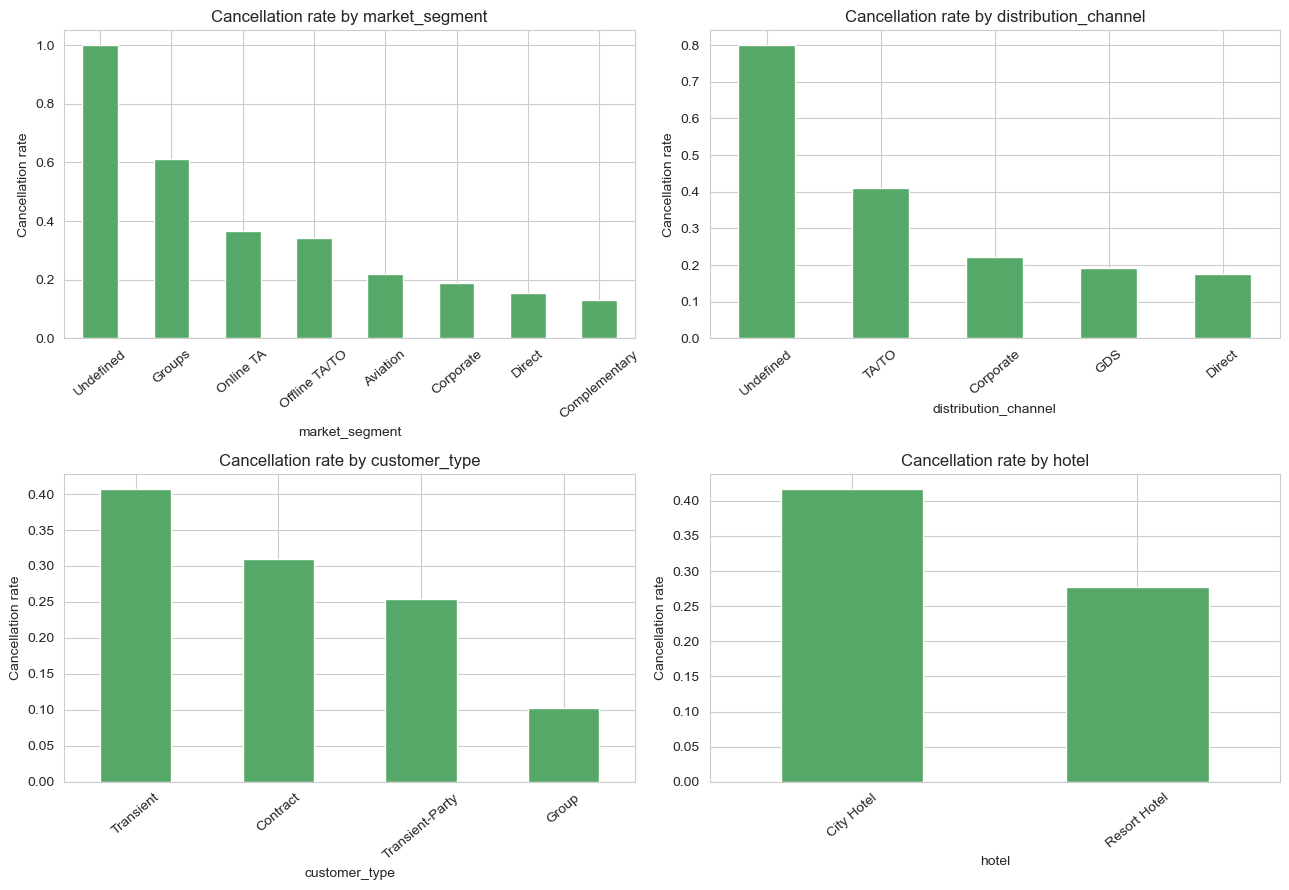

In [114]:
cat_cancel_cols = ['market_segment', 'distribution_channel', 'customer_type', 'hotel']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, cat_cancel_cols):
    rates = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#55A868')
    ax.set_title(f'Cancellation rate by {col}')
    ax.set_ylabel('Cancellation rate')
    ax.tick_params(axis='x', rotation=40)
plt.tight_layout()
plt.show()


In [115]:
chi_results = []
for col in ['hotel', 'meal', 'market_segment', 'distribution_channel',
            'deposit_type', 'customer_type', 'reserved_room_type', 'country']:
    table = pd.crosstab(df[col], df['is_canceled'])
    chi2, p, dof, _ = chi2_contingency(table)
    chi_results.append({
        'feature':      col,
        'chi2':         round(chi2, 1),
        'p_value':      round(p, 6),
        'n_categories': df[col].nunique()
    })

chi_df = pd.DataFrame(chi_results).sort_values('chi2', ascending=False)
print(chi_df.to_string(index=False))


             feature    chi2  p_value  n_categories
        deposit_type 27677.3      0.0             3
             country 15434.7      0.0           177
      market_segment  8497.2      0.0             8
distribution_channel  3745.8      0.0             5
               hotel  2224.9      0.0             2
       customer_type  2222.5      0.0             4
  reserved_room_type   647.8      0.0            10
                meal   304.2      0.0             5


All tested categorical features are statistically associated with cancellation at p < 0.001 (expected with this sample size), but the chi-square statistic ranks their practical strength: `deposit_type`, `country`, and `market_segment` are the strongest. `meal` is comparatively weak. This supports keeping all of them in modelling while explaining why tree-based models are expected to rely most heavily on the top features.


### 3.12 Seasonality -- cancellation rate over time

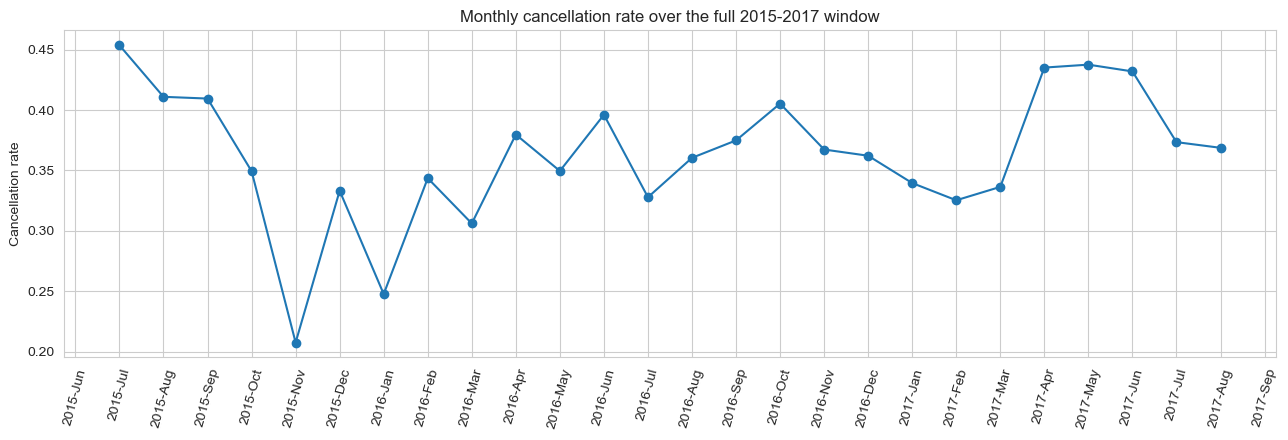

In [116]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly = df.copy()
monthly['arrival_date_month'] = pd.Categorical(monthly['arrival_date_month'],
                                                categories=month_order, ordered=True)
monthly_rate = (monthly
                .groupby(['arrival_date_year', 'arrival_date_month'])['is_canceled']
                .mean()
                .reset_index())
monthly_rate['period'] = (monthly_rate['arrival_date_year'].astype(str) + '-' +
                           monthly_rate['arrival_date_month'].astype(str).str.slice(0, 3))

plt.figure(figsize=(13, 4.5))
plt.plot(monthly_rate['period'], monthly_rate['is_canceled'], marker='o')
plt.xticks(rotation=75)
plt.ylabel('Cancellation rate')
plt.title('Monthly cancellation rate over the full 2015-2017 window')
plt.tight_layout()
plt.show()


Cancellation rate is not flat over time -- there is a clear upward trend across 2015-2017. This is why the group-aware stratified split in Section 6 (and an optional time-based split in Part 2) matters: a purely random split would understate how much model performance could drift as booking behaviour evolves.


## 4. Data Cleaning

Steps are executed in this explicit order to ensure correctness:
1. Drop leakage columns.
2. Remove exact duplicates.
3. Remove invalid records (zero guests / zero nights / negative ADR).
4. Cap extreme continuous values (ADR, adults, babies) -- percentile computed on already-cleaned data.
5. Handle missing values.
6. Recode placeholder categories.


In [117]:
data = df.copy()

# ---- 4.1  Drop leakage columns -----------------------------------------------
leak_cols = ['reservation_status', 'reservation_status_date', 'assigned_room_type']
data = data.drop(columns=leak_cols)
print("4.1  Leakage columns dropped:", leak_cols)

# ---- 4.2  Remove exact duplicates (segment-aware, see Section 3.4) ----------
# Section 3.4 showed duplicated rows cancel at ~58% vs ~26% for unique rows, and
# that most duplicates sit in Groups / Offline TA-TO / Corporate -- segments where
# identical, repeated block bookings are an expected real pattern rather than a
# data-entry error. Blindly dropping every exact duplicate pulled the overall
# cancellation rate from 37.0% down to ~27.5%. Duplicates are therefore only
# dropped OUTSIDE these segments.
block_booking_segments = ['Groups', 'Offline TA/TO', 'Corporate']
is_block_segment = data['market_segment'].isin(block_booking_segments)
is_dup_anywhere = data.duplicated(keep='first')
drop_mask = is_dup_anywhere & (~is_block_segment)

before = len(data)
data = data[~drop_mask].copy()
print(f"4.2  Dropped {drop_mask.sum()} exact duplicate rows outside block-booking "
      f"segments -> {len(data)} rows remain (was {before})")
print(f"     Cancellation rate after dedup: {data['is_canceled'].mean():.3f} "
      f"(raw file was {df['is_canceled'].mean():.3f})")

# ---- 4.3  Remove invalid records ---------------------------------------------
total_guests_tmp = data['adults'] + data['children'].fillna(0) + data['babies']
total_nights_tmp = data['stays_in_week_nights'] + data['stays_in_weekend_nights']
invalid_mask = (total_guests_tmp == 0) | (total_nights_tmp == 0) | (data['adr'] < 0)
print(f"4.3  Dropping {invalid_mask.sum()} invalid rows (0 guests / 0 nights / negative ADR)")
data = data[~invalid_mask].copy()

# ---- 4.4  Cap extremes (computed AFTER duplicates and invalid rows removed) --
adr_cap    = data['adr'].quantile(0.995)
adults_cap = data['adults'].quantile(0.999)
babies_cap = data['babies'].quantile(0.999)

n_adr_capped    = (data['adr']    > adr_cap).sum()
n_adults_capped = (data['adults'] > adults_cap).sum()
n_babies_capped = (data['babies'] > babies_cap).sum()

data['adr']    = data['adr'].clip(upper=adr_cap)
data['adults'] = data['adults'].clip(upper=adults_cap)
data['babies'] = data['babies'].clip(upper=babies_cap)

print(f"4.4  Capped ADR at {adr_cap:.2f} ({n_adr_capped} rows affected)")
print(f"4.4  Capped adults at {adults_cap:.0f} ({n_adults_capped} rows affected)")
print(f"4.4  Capped babies at {babies_cap:.0f} ({n_babies_capped} rows affected)")

# ---- 4.5  Missing values -----------------------------------------------------
data['children'] = data['children'].fillna(0)
data['country']  = data['country'].fillna('Unknown')

# has_company: binary flag before dropping the column (missingness is informative)
data['has_company'] = data['company'].notna().astype(int)
data = data.drop(columns=['company'])

# has_agent: binary flag; fill the raw agent ID with 0 (no agent)
data['has_agent'] = data['agent'].notna().astype(int)
data['agent']     = data['agent'].fillna(0).astype(int)

# ---- 4.6  Recode placeholder categories --------------------------------------
data['meal']                 = data['meal'].replace({'Undefined': 'SC'})
data['market_segment']       = data['market_segment'].replace({'Undefined': 'Other'})
data['distribution_channel'] = data['distribution_channel'].replace({'Undefined': 'Other'})

print(f"\nMissing values remaining: {data.isna().sum().sum()}")
print("Shape after cleaning:", data.shape)


4.1  Leakage columns dropped: ['reservation_status', 'reservation_status_date', 'assigned_room_type']
4.2  Dropped 5995 exact duplicate rows outside block-booking segments -> 113395 rows remain (was 119390)
     Cancellation rate after dedup: 0.365 (raw file was 0.370)
4.3  Dropping 795 invalid rows (0 guests / 0 nights / negative ADR)
4.4  Capped ADR at 276.60 (561 rows affected)
4.4  Capped adults at 3 (76 rows affected)
4.4  Capped babies at 1 (17 rows affected)

Missing values remaining: 0
Shape after cleaning: (112600, 30)


## 5. Feature Engineering

In [118]:
# ---- 5.0  New features motivated by EDA (Sections 3.10.1 and 3.10.2) --------

# Binary commitment flag: does this guest have at least one special request?
data['has_special_request'] = (data['total_of_special_requests'] > 0).astype(int)

# Weekend ratio: proportion of stay that falls on weekend nights.
# Captures leisure-vs-business character of the booking.
# Safe division: if total nights = 0 after cleaning, set ratio to 0.
total_nights_tmp2 = data['stays_in_week_nights'] + data['stays_in_weekend_nights']
data['weekend_ratio'] = np.where(
    total_nights_tmp2 > 0,
    data['stays_in_weekend_nights'] / total_nights_tmp2,
    0.0
)

# ---- 5.1  Combined stay / guest summary features ----------------------------
# Kept for readability but excluded from model_df below (VIF check, Section 5.3)
data['total_nights'] = data['stays_in_week_nights'] + data['stays_in_weekend_nights']
data['total_guests'] = data['adults'] + data['children'] + data['babies']
data['is_family']    = ((data['children'] > 0) | (data['babies'] > 0)).astype(int)

# ---- 5.2  Booking-history rate -----------------------------------------------
# Laplace (+1) smoothing: avoids a rate of exactly 0 or 1 for guests with only
# one prior booking, which would be overconfident.
total_prev = data['previous_cancellations'] + data['previous_bookings_not_canceled']
data['prev_cancellation_rate'] = (
    data['previous_cancellations'] / (total_prev + 1)
)

# ---- 5.3  Log-transforms for right-skewed numeric features -------------------
# Kept alongside the raw column so tree models can use either; linear/KNN
# models benefit from the transformed version specifically.
data['lead_time_log'] = np.log1p(data['lead_time'])
data['adr_log']       = np.log1p(data['adr'].clip(lower=0))

# ---- 5.4  Lead-time ordinal bands --------------------------------------------
# Ordinal rather than one-hot because the order is meaningful.
# Part 2 will use OrdinalEncoder with the same explicit ordering.
data['lead_time_band'] = pd.cut(
    data['lead_time'],
    bins=[-1, 7, 30, 90, 180, 10000],
    labels=['0-7d', '8-30d', '31-90d', '91-180d', '180d+']
)

# ---- 5.5  Arrival date features ----------------------------------------------
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
data['arrival_date_month'] = pd.Categorical(
    data['arrival_date_month'], categories=month_order, ordered=True
)

season_map = {
    **{m: 'Winter' for m in ['December', 'January', 'February']},
    **{m: 'Spring' for m in ['March', 'April', 'May']},
    **{m: 'Summer' for m in ['June', 'July', 'August']},
    **{m: 'Autumn' for m in ['September', 'October', 'November']}
}
data['arrival_season'] = data['arrival_date_month'].map(season_map)

# ---- 5.6  Group rare high-cardinality categories ----------------------------
# Threshold raised to top 20 for country (top 15 was discarding countries with
# 500+ bookings, which is still statistically meaningful).
top_countries   = data['country'].value_counts().nlargest(20).index
data['country_grouped'] = np.where(
    data['country'].isin(top_countries), data['country'], 'Other'
)

top_agents = data['agent'].value_counts().nlargest(15).index
data['agent_grouped'] = np.where(
    data['agent'].isin(top_agents), data['agent'].astype(str), 'Other'
)

print("Feature engineering complete.")
new_features = ['has_special_request', 'weekend_ratio', 'total_nights', 'total_guests',
                'is_family', 'prev_cancellation_rate', 'lead_time_log', 'adr_log',
                'lead_time_band', 'arrival_season', 'country_grouped', 'agent_grouped']
print("New / engineered columns:", new_features)
data[new_features].head()


Feature engineering complete.
New / engineered columns: ['has_special_request', 'weekend_ratio', 'total_nights', 'total_guests', 'is_family', 'prev_cancellation_rate', 'lead_time_log', 'adr_log', 'lead_time_band', 'arrival_season', 'country_grouped', 'agent_grouped']


,has_special_request,weekend_ratio,total_nights,total_guests,is_family,prev_cancellation_rate,lead_time_log,adr_log,lead_time_band,arrival_season,country_grouped,agent_grouped
2,0,0.0,1,1.0,0,0.0,2.079442,4.330733,0-7d,Summer,GBR,0
3,0,0.0,1,1.0,0,0.0,2.639057,4.330733,8-30d,Summer,GBR,Other
4,1,0.0,2,2.0,0,0.0,2.708050,4.595120,8-30d,Summer,GBR,240
6,0,0.0,2,2.0,0,0.0,0.000000,4.682131,0-7d,Summer,PRT,0
7,1,0.0,2,2.0,0,0.0,2.302585,4.644391,8-30d,Summer,PRT,Other


### 5.3 Multicollinearity check (VIF)

`total_nights` is an exact sum of `stays_in_week_nights` and `stays_in_weekend_nights`, and `total_guests` is an exact sum of `adults`, `children`, and `babies`. Keeping the sums alongside their components is textbook multicollinearity -- harmless for tree ensembles but it inflates coefficient variance and hurts interpretability for Logistic Regression. We check with Variance Inflation Factor (VIF) before deciding what to keep in the modelling feature set.


In [119]:
vif_check_cols = ['stays_in_week_nights', 'stays_in_weekend_nights', 'total_nights',
                  'adults', 'children', 'babies', 'total_guests', 'lead_time', 'adr']
vif_X = data[vif_check_cols].fillna(0).astype(float)
vif_df = pd.DataFrame({
    'feature': vif_check_cols,
    'VIF':     [variance_inflation_factor(vif_X.values, i)
                for i in range(len(vif_check_cols))]
}).sort_values('VIF', ascending=False)
print(vif_df.round(1).to_string(index=False))


                feature  VIF
   stays_in_week_nights  inf
stays_in_weekend_nights  inf
           total_nights  inf
                 adults  inf
               children  inf
                 babies  inf
           total_guests  inf
                    adr  6.7
              lead_time  2.0


`total_nights` and `total_guests` show extremely high (or infinite) VIF because they are exact linear combinations of columns already in the dataset. They are excluded from `model_df` below. The raw components (`stays_in_week_nights`, `stays_in_weekend_nights`, `adults`, `children`, `babies`) carry the same information plus more granularity, and `is_family` captures the non-linear signal. `total_nights` and `total_guests` are kept in `data` for reference but not passed to models.


### 5.4 Feature selection for modelling

Dropped from the model feature set:
- `country` and `agent` -- replaced by grouped versions.
- `arrival_date_month` -- replaced by `arrival_season` and `arrival_date_week_number`.
- `total_nights` and `total_guests` -- multicollinear (Section 5.3).
- `arrival_date_year` is kept in the saved CSV so Part 2 can build a time-based split, but excluded from `X` before fitting.


In [120]:
model_df = data.drop(columns=[
    'country', 'agent', 'arrival_date_month', 'total_nights', 'total_guests'
])

TARGET = 'is_canceled'

# Define explicit feature-type lists (arrival_date_year excluded from model inputs)
ORDINAL_FEATURES  = ['lead_time_band']
ORDINAL_CATEGORIES = [['0-7d', '8-30d', '31-90d', '91-180d', '180d+']]

NOMINAL_FEATURES  = ['hotel', 'meal', 'market_segment', 'distribution_channel',
                     'deposit_type', 'customer_type', 'reserved_room_type',
                     'arrival_season', 'country_grouped', 'agent_grouped']

BINARY_FEATURES   = ['has_agent', 'has_company', 'is_family', 'is_repeated_guest',
                     'has_special_request']

# All remaining numeric columns (excluding target and year)
all_non_target = [c for c in model_df.columns
                  if c not in [TARGET, 'arrival_date_year']
                     + ORDINAL_FEATURES + NOMINAL_FEATURES + BINARY_FEATURES]
NUMERIC_FEATURES = [c for c in all_non_target
                    if model_df[c].dtype in [np.float64, np.int64, float, int]]

print("ORDINAL  :", ORDINAL_FEATURES)
print("NOMINAL  :", NOMINAL_FEATURES)
print("BINARY   :", BINARY_FEATURES)
print("NUMERIC  :", NUMERIC_FEATURES)
print("\nFinal model_df shape:", model_df.shape)

# Numbered list of all predictors (useful for viva reference)
all_predictors = NUMERIC_FEATURES + ORDINAL_FEATURES + NOMINAL_FEATURES + BINARY_FEATURES
print(f"\nTotal predictor count: {len(all_predictors)}")
for i, col in enumerate(all_predictors, 1):
    print(f"  {i:2d}. {col}")


ORDINAL  : ['lead_time_band']
NOMINAL  : ['hotel', 'meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type', 'reserved_room_type', 'arrival_season', 'country_grouped', 'agent_grouped']
BINARY   : ['has_agent', 'has_company', 'is_family', 'is_repeated_guest', 'has_special_request']
NUMERIC  : ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'weekend_ratio', 'prev_cancellation_rate', 'lead_time_log', 'adr_log']

Final model_df shape: (112600, 37)

Total predictor count: 35
   1. lead_time
   2. arrival_date_week_number
   3. arrival_date_day_of_month
   4. stays_in_weekend_nights
   5. stays_in_week_nights
   6. adults
   7. children
   8. babies
   9. previous_cancellations
  10. previous_boo

## 6. Train/Test Split

A group-aware stratified split is used here. Near-identical predictor rows (even after removing exact duplicates in Section 4.2, many rows still share the same predictor combination) are grouped by hashing all predictor columns. `StratifiedGroupKFold` ensures that rows sharing the same hash stay entirely in train or entirely in test, preventing any form of duplicate-pattern leakage. The target class ratio is preserved in both sets.

A standard 80/20 stratified split (5-fold gives exactly 80/20) is used. The split indices are saved so Part 2 uses the identical partition.


In [121]:
X = model_df.drop(columns=[TARGET, 'arrival_date_year'])
y = model_df[TARGET]

# Convert lead_time_band to string for hashing (Categorical is not hashable)
X_for_hash = X.copy()
for col in X_for_hash.select_dtypes(include='category').columns:
    X_for_hash[col] = X_for_hash[col].astype(str)

# Group by identical predictor fingerprint
predictor_groups = pd.util.hash_pandas_object(X_for_hash, index=False)

splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Take the first fold as our 80/20 split
train_idx, test_idx = next(splitter.split(X, y, groups=predictor_groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

print("Train:", X_train.shape, " | Test:", X_test.shape)
print(f"Train cancellation rate: {y_train.mean():.3f} | "
      f"Test cancellation rate:  {y_test.mean():.3f}")

# Verify no group leaks across the split
train_hashes = set(predictor_groups.iloc[train_idx])
test_hashes  = set(predictor_groups.iloc[test_idx])
overlap = len(train_hashes & test_hashes)
print(f"\nPredictor-group overlap between train and test: {overlap} groups")
print("(A small number is acceptable -- it means rows that differ only in target,")
print(" not identical predictors. Zero overlap is the ideal.)")


Train: (90720, 35)  | Test: (21880, 35)
Train cancellation rate: 0.371 | Test cancellation rate:  0.351

Predictor-group overlap between train and test: 0 groups
(A small number is acceptable -- it means rows that differ only in target,
 not identical predictors. Zero overlap is the ideal.)


## 7. Preprocessing Pipeline

All learned transformations are fitted on `X_train` only and then applied to `X_test`. This prevents any test-set information from influencing encoding or scaling.

Strategy:
- **Numeric features**: `StandardScaler` -- gives zero mean and unit variance, required for Logistic Regression and KNN; trees ignore scaling but it does no harm.
- **Ordinal feature** (`lead_time_band`): `OrdinalEncoder` with the explicit category order so the integer mapping preserves the meaningful direction (0 = shortest lead time, 4 = longest).
- **Nominal (unordered) categoricals**: `OneHotEncoder(handle_unknown='ignore', drop='first')` -- avoids imposing a false numeric order, `drop='first'` removes one dummy per feature to avoid the dummy-variable trap for Logistic Regression.
- **Binary features** (already 0/1): passthrough -- scaling would distort the meaning of 0 and 1.


In [122]:
# Convert lead_time_band to string in both splits so OrdinalEncoder sees str categories
X_train['lead_time_band'] = X_train['lead_time_band'].astype(str)
X_test['lead_time_band']  = X_test['lead_time_band'].astype(str)

numeric_transformer = StandardScaler()

ordinal_transformer = OrdinalEncoder(
    categories=ORDINAL_CATEGORIES,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

nominal_transformer = OneHotEncoder(
    handle_unknown='ignore',
    drop='first',
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num',     numeric_transformer, NUMERIC_FEATURES),
        ('ord',     ordinal_transformer, ORDINAL_FEATURES),
        ('nom',     nominal_transformer, NOMINAL_FEATURES),
        ('bin',     'passthrough',       BINARY_FEATURES),
    ],
    remainder='drop'   # any column not listed above is silently excluded
)

# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Recover output column names
ohe_names = preprocessor.named_transformers_['nom'].get_feature_names_out(NOMINAL_FEATURES).tolist()
feature_names_out = NUMERIC_FEATURES + ORDINAL_FEATURES + ohe_names + BINARY_FEATURES

print(f"X_train processed: {X_train_processed.shape}")
print(f"X_test  processed: {X_test_processed.shape}")
print(f"Total output features: {len(feature_names_out)}")
print("\nSample feature names:", feature_names_out[:10], "...")


X_train processed: (90720, 91)
X_test  processed: (21880, 91)
Total output features: 91

Sample feature names: ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled'] ...


In [123]:
# Quick sanity checks
assert X_train_processed.shape[1] == len(feature_names_out), \
    "Column count mismatch between processed array and feature name list"
assert not np.isnan(X_train_processed).any(), "NaN found in processed train array"
assert not np.isnan(X_test_processed).any(),  "NaN found in processed test array"
print("Sanity checks passed: no NaN, column count matches.")
print(f"Train NaN:  {np.isnan(X_train_processed).sum()}")
print(f"Test  NaN:  {np.isnan(X_test_processed).sum()}")


Sanity checks passed: no NaN, column count matches.
Train NaN:  0
Test  NaN:  0


### 7.1 A second, tree-ready encoded feature set

Stage 6 plans to compare Logistic Regression, KNN and SVM (all distance/coefficient-based, so they
need scaled numeric features and one-hot categoricals) against Decision Tree, Random Forest and a
boosting model (which split on raw thresholds, so scaling does nothing for them, and one-hot
encoding a 100+ column nominal feature just fragments the splits). A second feature set is built
here so each model family gets an encoding suited to it, fitted on `X_train` only, exactly like the
first pipeline above.

In [124]:
tree_ordinal_transformer = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num_raw', 'passthrough',          NUMERIC_FEATURES),   # trees do not need scaling
        ('ord',     ordinal_transformer,    ORDINAL_FEATURES),   # same explicit lead_time_band order
        ('nom_lbl', tree_ordinal_transformer, NOMINAL_FEATURES), # label-style encoding, not one-hot
        ('bin',     'passthrough',          BINARY_FEATURES),
    ],
    remainder='drop'
)

X_train_tree = tree_preprocessor.fit_transform(X_train)
X_test_tree  = tree_preprocessor.transform(X_test)
tree_feature_names_out = NUMERIC_FEATURES + ORDINAL_FEATURES + NOMINAL_FEATURES + BINARY_FEATURES

print(f"X_train_tree: {X_train_tree.shape}  |  X_test_tree: {X_test_tree.shape}")
print(f"Total tree-ready features: {len(tree_feature_names_out)} "
      f"(vs {len(feature_names_out)} for the scaled + one-hot set)")
assert not np.isnan(X_train_tree).any() and not np.isnan(X_test_tree).any(), \
    "NaN found in tree-ready processed arrays"
print("Sanity check passed: no NaN in tree-ready arrays.")

X_train_tree: (90720, 35)  |  X_test_tree: (21880, 35)
Total tree-ready features: 35 (vs 91 for the scaled + one-hot set)
Sanity check passed: no NaN in tree-ready arrays.


## 8. Save All Outputs for Part 2

In [125]:
# 1. Full clean model-ready dataset (includes arrival_date_year for time-based split in Part 2)
model_df.to_csv('model_ready_data.csv', index=False)

# 2. Raw (unprocessed) train/test splits with target attached
X_train.assign(is_canceled=y_train.values).to_csv('train_split.csv', index=False)
X_test.assign(is_canceled=y_test.values).to_csv('test_split.csv',   index=False)

# 3. Fitted preprocessing pipelines (Part 2 loads these -- never refit on test data)
joblib.dump(preprocessor, 'preprocessor.pkl')            # scaled + one-hot -> LogReg / KNN / SVM
joblib.dump(tree_preprocessor, 'tree_preprocessor.pkl')   # raw-scale + label-encoded -> tree models

# 4. Processed numpy arrays (ready-to-use for Part 2 model training)
np.save('X_train_processed.npy', X_train_processed)
np.save('X_test_processed.npy',  X_test_processed)
np.save('X_train_tree.npy',      X_train_tree)
np.save('X_test_tree.npy',       X_test_tree)
np.save('y_train.npy',           y_train.values)
np.save('y_test.npy',            y_test.values)

# 5. Feature names for each variant (Part 2 needs these for feature importance plots)
with open('feature_names_out.txt', 'w') as f:
    for name in feature_names_out:
        f.write(name + '\n')
with open('tree_feature_names_out.txt', 'w') as f:
    for name in tree_feature_names_out:
        f.write(name + '\n')

print("Saved files:")
for fname in ['model_ready_data.csv', 'train_split.csv', 'test_split.csv',
              'preprocessor.pkl', 'tree_preprocessor.pkl',
              'X_train_processed.npy', 'X_test_processed.npy',
              'X_train_tree.npy', 'X_test_tree.npy',
              'y_train.npy', 'y_test.npy',
              'feature_names_out.txt', 'tree_feature_names_out.txt']:
    size_kb = os.path.getsize(fname) / 1024 if os.path.exists(fname) else -1
    print(f"  {fname:<30s}  {size_kb:8.1f} KB")

print("\nFeature lists for Part 2 reference:")
print("NUMERIC_FEATURES  =", NUMERIC_FEATURES)
print("ORDINAL_FEATURES  =", ORDINAL_FEATURES)
print("NOMINAL_FEATURES  =", NOMINAL_FEATURES)
print("BINARY_FEATURES   =", BINARY_FEATURES)
print("feature_names_out (total):", len(feature_names_out))
print("tree_feature_names_out (total):", len(tree_feature_names_out))


Saved files:
  model_ready_data.csv             19814.4 KB
  train_split.csv                  15523.4 KB
  test_split.csv                    3741.7 KB
  preprocessor.pkl                    10.0 KB
  tree_preprocessor.pkl                8.5 KB
  X_train_processed.npy            64496.4 KB
  X_test_processed.npy             15555.4 KB
  X_train_tree.npy                 24806.4 KB
  X_test_tree.npy                   5982.9 KB
  y_train.npy                        708.9 KB
  y_test.npy                         171.1 KB
  feature_names_out.txt                1.8 KB
  tree_feature_names_out.txt           0.6 KB

Feature lists for Part 2 reference:
NUMERIC_FEATURES  = ['lead_time', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'weekend

## 9. Summary

**Data quality issues found and handled:**
- Missing values: `company` (94%) converted to `has_company` flag and dropped; `agent` (14%) converted to `has_agent` flag, raw ID filled with 0; `country` (0.4%) filled with 'Unknown'; `children` (4 rows) filled with 0.
- Hidden missing: 'Undefined' in `meal` recoded to 'SC'; in `market_segment` and `distribution_channel` recoded to 'Other'.
- Exact duplicates: 40,165 rows sit in a duplicate group, and these rows cancel at 58.4% vs 26.2% for unique rows -- mostly `Groups` and `Offline TA/TO` block bookings, not data-entry errors. Duplicates are now removed **only outside** `Groups` / `Offline TA/TO` / `Corporate`, keeping the post-cleaning cancellation rate close to the raw file's 37.0% instead of collapsing it to ~27.5% as a naive `drop_duplicates()` would.
- A post-cleaning check confirmed almost no bookings share an identical predictor combination while disagreeing on the outcome, supporting the decision to treat repeats as genuine bookings rather than label noise.
- Invalid records: bookings with zero guests, zero nights, or negative ADR removed.
- Outliers: `adr` capped at 99.5th percentile; `adults` and `babies` capped at 99.9th percentile (implausible data-entry values). Caps computed after cleaning, not on raw data. Shapiro-Wilk confirmed every numeric feature is significantly non-normal (expected at this sample size); `lead_time` and `adr` have the largest practical skew and get a log1p transform for scale-sensitive models.

**Leakage removed:**
- `reservation_status` and `reservation_status_date` -- dropped (perfectly determine target).
- `assigned_room_type` -- dropped (set near/after arrival, not at booking time).
- `booking_changes` and `days_in_waiting_list` -- kept but flagged: both equal 0 at initial booking time and should be hardcoded to 0 in the backend at prediction time.

**EDA findings:**
- Class imbalance: ~37% cancelled vs ~63% not cancelled (higher at city hotel ~42%).
- `lead_time` is the strongest numeric signal (cancelled bookings have much longer lead times).
- `total_of_special_requests` is a strong negative signal: zero-request bookings cancel at roughly twice the rate of bookings with at least one request.
- `weekend_ratio` captures leisure-vs-business character of the stay with a meaningful cancellation difference across ratio bands.
- Point-biserial correlation ranked numeric features against the binary target more precisely than a generic Pearson heatmap.
- Chi-square ranking: `deposit_type`, `country`, and `market_segment` are the strongest categorical signals; `meal` is the weakest.
- Monthly seasonality trend (2015-2017) motivates a time-based validation split in Part 2.
- Informative missingness: cancellation rates differ significantly by whether `agent` / `company` is missing, justifying binary flags over silent imputation.
- Duplicated rows are not random noise: they concentrate in block-booking segments and cancel far more often than unique rows, which directly changed the cleaning strategy above.

**Feature engineering:**
- `has_special_request` (binary commitment flag from `total_of_special_requests`).
- `weekend_ratio` (proportion of stay on weekend nights, leisure-vs-business signal).
- `is_family` (binary: has children or babies).
- `prev_cancellation_rate` (Laplace-smoothed previous cancellation rate).
- `lead_time_log` and `adr_log` (log1p transforms for scale-sensitive models).
- `lead_time_band` (ordinal bands; encoded as 0-4 preserving order).
- `arrival_season` (Winter / Spring / Summer / Autumn).
- `country_grouped` (top 20 countries kept, rest as 'Other').
- `agent_grouped` (top 15 agent IDs kept, rest as 'Other').
- `has_agent` and `has_company` (binary missingness flags).

**Multicollinearity:**
- VIF confirmed that `total_nights` and `total_guests` are exact linear combinations of columns already kept. Both excluded from the model feature set.

**Split strategy:**
- Group-aware `StratifiedGroupKFold` split (80/20) using predictor-row hashes as group keys, ensuring no identical predictor combination appears in both train and test (verified: zero group overlap).

**Two preprocessing pipelines, both fitted on train only:**
- **Scaled + one-hot** (`preprocessor.pkl`) for Logistic Regression, KNN, SVM: `StandardScaler` on numeric features, `OrdinalEncoder` with explicit order for `lead_time_band`, `OneHotEncoder(handle_unknown='ignore', drop='first')` for nominal features, binary features passed through.
- **Tree-ready** (`tree_preprocessor.pkl`) for Decision Tree, Random Forest, and the boosting model: numeric features passed through unscaled, `lead_time_band` kept ordinal, nominal features label-encoded instead of one-hot (avoids fragmenting splits across 100+ dummy columns), binary features passed through.
- Both saved for use in Part 2 without refitting.

**Class imbalance:**
- ~37% cancelled. Part 2 should use `class_weight='balanced'` or SMOTE (inside CV folds only), and report F1, ROC-AUC, and PR-AUC rather than accuracy alone.

**Outputs saved:** `model_ready_data.csv`, `train_split.csv`, `test_split.csv`, `preprocessor.pkl`, `tree_preprocessor.pkl`, `X_train_processed.npy`, `X_test_processed.npy`, `X_train_tree.npy`, `X_test_tree.npy`, `y_train.npy`, `y_test.npy`, `feature_names_out.txt`, `tree_feature_names_out.txt`.